# Sentiment and Thematic Analysis

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import nltk
import os
import sys

sys.path.append(os.path.abspath(".."))

from scripts.load import load_files
from scripts.sentiment import sentiment_analysis
from scripts.theme import assign_theme
from scripts.preprocess import clean_text
from scripts.text_analysis import extract_keywords

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\megde\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [41]:
df = load_files()

all_reviews_df = pd.concat(
    [df["abyssinia"], df["cbe"], df["dashen"]],
    ignore_index=True
)


In [44]:
sentiment_analysis(all_reviews_df)

Running Transformer Sentiment: 100%|██████████| 94/94 [01:54<00:00,  1.22s/it]


Transformer Sentiment Distribution:
transformer_sentiment_label
POSITIVE    0.61
NEGATIVE    0.39
Name: proportion, dtype: float64


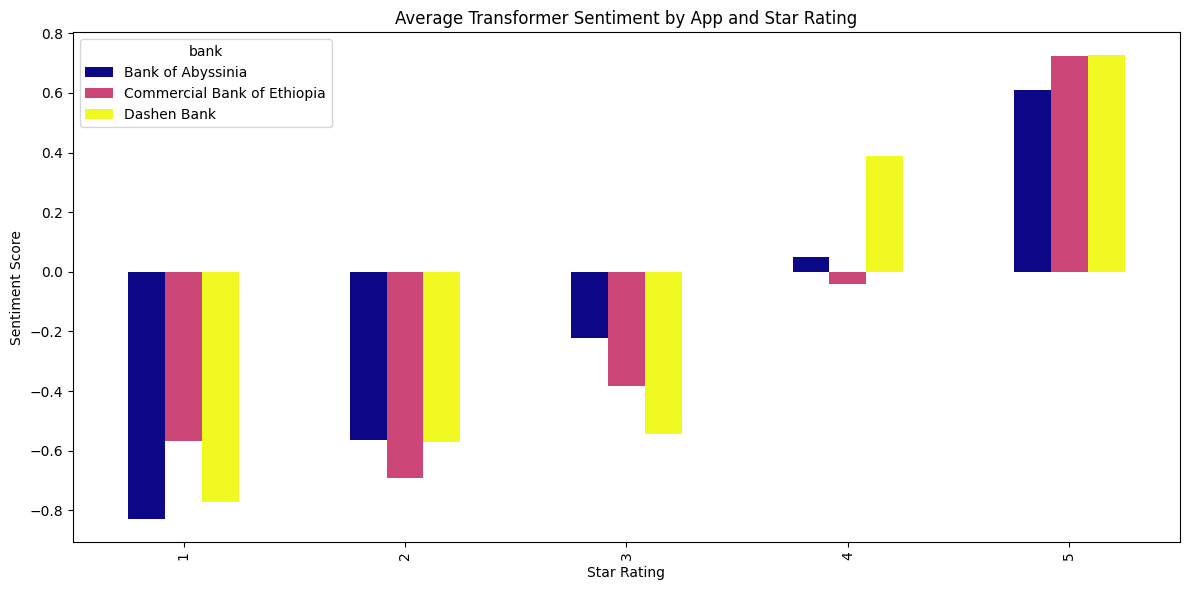

In [45]:
sent = all_reviews_df.groupby(
    ["bank", "rating"]
)["transformer_sentiment_score"].mean().unstack()
sent.T.plot(kind="bar", figsize=(12, 6), colormap="plasma")
plt.title("Average Transformer Sentiment by App and Star Rating")
plt.xlabel("Star Rating")
plt.ylabel("Sentiment Score")
plt.tight_layout()
plt.show()

In [46]:
all_reviews_df["clean_review"] = all_reviews_df["review"].apply(clean_text)

In [47]:
for bank, df_bank in all_reviews_df.groupby("bank"):
    print("\n", bank)
    print(extract_keywords(df_bank))


 Bank of Abyssinia
[('good', np.float64(77.64719639006769)), ('app', np.float64(43.57681207474004)), ('best', np.float64(24.064548768777975)), ('nice', np.float64(20.15640516620073)), ('boa', np.float64(16.206411705658233)), ('bank', np.float64(12.097953174976485)), ('working', np.float64(11.241813181948343)), ('work', np.float64(9.090782311752783)), ('fast', np.float64(8.528027528420056)), ('mobile', np.float64(8.519698925961677))]

 Commercial Bank of Ethiopia
[('good', np.float64(89.95775611116082)), ('app', np.float64(36.180150621173446)), ('nice', np.float64(27.9325561773896)), ('best', np.float64(25.68471436502839)), ('ok', np.float64(21.0)), ('cbe', np.float64(11.870862226382263)), ('like', np.float64(9.988934202833772)), ('working', np.float64(9.087000153606503)), ('nice app', np.float64(9.042550036702206)), ('use', np.float64(8.767130003711731))]

 Dashen Bank
[('good', np.float64(57.11037472946738)), ('app', np.float64(41.98544843473699)), ('nice', np.float64(24.893267296339

In [48]:
all_reviews_df["theme"] = all_reviews_df["clean_review"].apply(assign_theme)
print(all_reviews_df["theme"].value_counts())

theme
Other                 1309
UI/UX                   74
Transaction Issues      50
Performance Issues      45
Account Issues          22
Name: count, dtype: int64


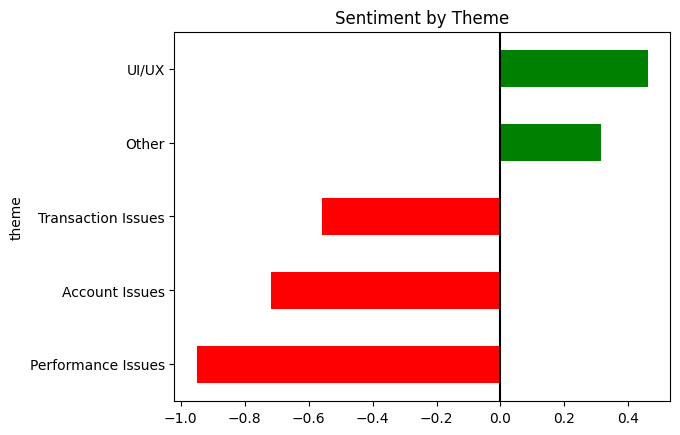

In [49]:
theme_sentiment = all_reviews_df.groupby("theme")["transformer_sentiment_score"].mean().sort_values()

colors = ["red" if x < 0 else "green" for x in theme_sentiment.values]

theme_sentiment.plot(kind="barh", color=colors)
plt.axvline(0, color="black")
plt.title("Sentiment by Theme")
plt.show()

In [51]:
final_df = all_reviews_df[
    [
        "review_id",
        "review",
        "transformer_sentiment_label",
        "transformer_sentiment_score",
        "theme"
    ]
]

final_df = final_df.rename(columns={
    "review": "review_text",
    "transformer_sentiment_label": "sentiment_label",
    "transformer_sentiment_score": "sentiment_score",
    "theme": "identified_theme"
})

final_df.to_csv("../data/processed/final_reviews.csv", index=False)